# Importações

In [937]:
# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Bibliotecas de EDA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv(r"data\academia_redfit.csv")

# Análise inicial do nosso dataframe

In [938]:
df.head()

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária


In [939]:
print("======= Informações básicas sobre o nosso dataset =======")
print(df.info())
print(df.describe())

print(f"\nNúmero de Linhas e Colunas: {df.shape}")

======= Informações básicas sobre o nosso dataset =======
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   str    
 2   frequencia_semanal_treino  949 non-null    float64
 3   tipo_atividade             1000 non-null   str    
 4   tempo_medio_exercicio      954 non-null    float64
 5   minutos_totais_semana      905 non-null    float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   str    
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   str    
 11  estado                     1000 non-null   str    
dtypes: float64(6), int64(1), str(5)
memory usage: 93.9 KB
None

In [940]:
print("==== Quantidade de valores nulos ====")
print(df.isnull().sum())

==== Quantidade de valores nulos ====
idade                         0
sexo                          0
frequencia_semanal_treino    51
tipo_atividade                0
tempo_medio_exercicio        46
minutos_totais_semana        95
preco_plano                   0
possui_nutricionista          0
primeiro_PGC                  0
ultimo_PGC                    0
data_matricula                0
estado                        0
dtype: int64


In [941]:
# Verificando os valores existentes nas colunas categóricas
colunas_categoricas = ['sexo', 'tipo_atividade', 'possui_nutricionista', 'estado']
for coluna in colunas_categoricas:
    print(f'\nValores na coluna {coluna}: {df[coluna].unique()}')


Valores na coluna sexo: <StringArray>
['Outro', 'Masculino', 'Feminino']
Length: 3, dtype: str

Valores na coluna tipo_atividade: <StringArray>
[   'Natação',       'Yoga',     'Cardio',   'CrossFit', 'Musculação',
    'Futebol',    'Natacao',     'Soccer',        'Fut',   'Swimming']
Length: 10, dtype: str

Valores na coluna possui_nutricionista: <StringArray>
['Não', 'Sim']
Length: 2, dtype: str

Valores na coluna estado: <StringArray>
['Ativa', 'Sedentária']
Length: 2, dtype: str


In [942]:
# Verificando a frequência em que cada valor aparece nessas colunas categóricas
for coluna in colunas_categoricas:
  print(f"\n==== Frequência dos valores da coluna: {coluna} ====")
  print(df[coluna].value_counts())


==== Frequência dos valores da coluna: sexo ====
sexo
Masculino    349
Outro        340
Feminino     311
Name: count, dtype: int64

==== Frequência dos valores da coluna: tipo_atividade ====
tipo_atividade
Yoga          195
Cardio        181
CrossFit      164
Musculação    160
Futebol       143
Natação       133
Fut             9
Swimming        6
Natacao         5
Soccer          4
Name: count, dtype: int64

==== Frequência dos valores da coluna: possui_nutricionista ====
possui_nutricionista
Não    514
Sim    486
Name: count, dtype: int64

==== Frequência dos valores da coluna: estado ====
estado
Ativa         834
Sedentária    166
Name: count, dtype: int64


In [943]:
# Tipo dos dados das colunas do dataframe
f"Tipos das colunas: {df.dtypes.unique()}"

"Tipos das colunas: [dtype('int64') <StringDtype(storage='python', na_value=nan)>\n dtype('float64')]"

# Limpeza dos dados

## Verificação

In [944]:
print("==== Quantidade de valores ausentes ====")
print(df.isnull().sum())

==== Quantidade de valores ausentes ====
idade                         0
sexo                          0
frequencia_semanal_treino    51
tipo_atividade                0
tempo_medio_exercicio        46
minutos_totais_semana        95
preco_plano                   0
possui_nutricionista          0
primeiro_PGC                  0
ultimo_PGC                    0
data_matricula                0
estado                        0
dtype: int64


In [945]:
print("\n==== Verificação de tipos incorretos nas colunas ====")
print(df.info())


==== Verificação de tipos incorretos nas colunas ====
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   str    
 2   frequencia_semanal_treino  949 non-null    float64
 3   tipo_atividade             1000 non-null   str    
 4   tempo_medio_exercicio      954 non-null    float64
 5   minutos_totais_semana      905 non-null    float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   str    
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   str    
 11  estado                     1000 non-null   str    
dtypes: float64(6), int64(1), str(5)
memory usage: 93.9 KB
None


## Tratando valores nulos e outliers

### Coluna 'tempo_medio_exercicio'

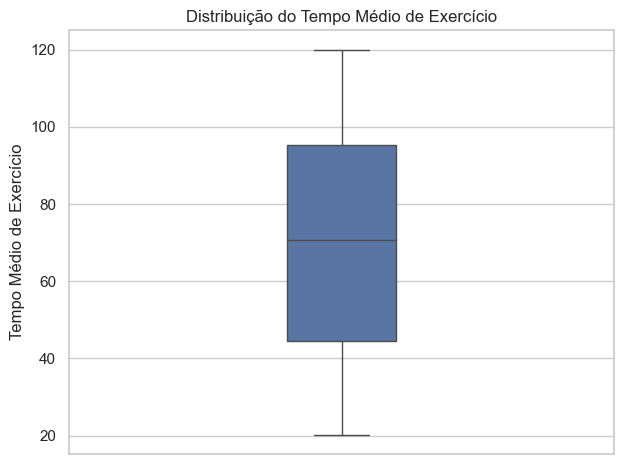

In [946]:
sns.boxplot(data=df, y='tempo_medio_exercicio', width=0.2)

plt.title('Distribuição do Tempo Médio de Exercício')
plt.ylabel('Tempo Médio de Exercício')
plt.tight_layout()
plt.show()

In [947]:
df['tempo_medio_exercicio'].describe()

count    954.000000
mean      70.140776
std       29.475029
min       20.200000
25%       44.525000
50%       70.550000
75%       95.200000
max      120.000000
Name: tempo_medio_exercicio, dtype: float64

#### Conclusões:
- Sem outliers visíveis
- Existe uma pequena assimetria para cima, o que puxa a distribuição para cima e justifica o uso da mediana para preencher valores nulos

#### Preenchimento

In [948]:
# Preenchendo os valores nulos com a mediana
df['tempo_medio_exercicio'] = df['tempo_medio_exercicio'].fillna(df['tempo_medio_exercicio'].median())

In [949]:
# Checando se o preenchimento funcionou
df['tempo_medio_exercicio'].value_counts(normalize=True)  
df['tempo_medio_exercicio'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

### Coluna 'frequencia_semanal_treino'

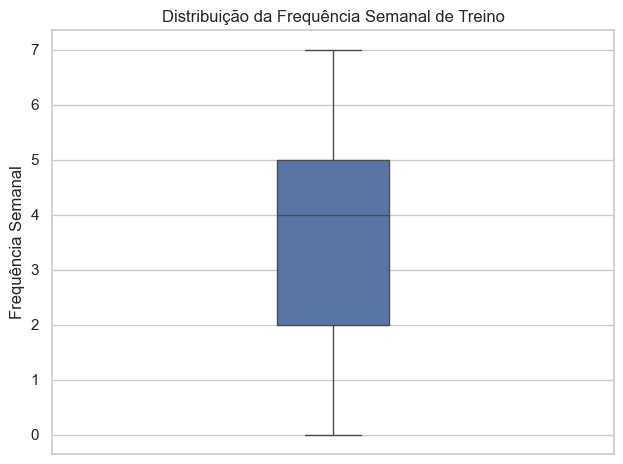

In [950]:
sns.boxplot(data=df, y='frequencia_semanal_treino', width=0.2)

plt.title('Distribuição da Frequência Semanal de Treino')
plt.ylabel('Frequência Semanal')
plt.tight_layout()
plt.show()

In [951]:
df['frequencia_semanal_treino'].describe()

count    949.000000
mean       3.559536
std        2.251555
min        0.000000
25%        2.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: frequencia_semanal_treino, dtype: float64

#### Conclusões:
- Sem outliers visíveis
- A assimetria para baixo indica que existem mais alunos com uma baixa frequência, o que puxa a distribuição para baixo e justifica o uso da mediana para preencher os valores nulos

#### Preenchimento

In [952]:
# Preenchendo os valores nulos com a mediana
df['frequencia_semanal_treino'] = df['frequencia_semanal_treino'].fillna(df['frequencia_semanal_treino'].median())

In [953]:
# Checando se o preenchimento funcionou
df['frequencia_semanal_treino'].value_counts(normalize=True)  
df['frequencia_semanal_treino'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

### Coluna 'minutos_totais_semana'

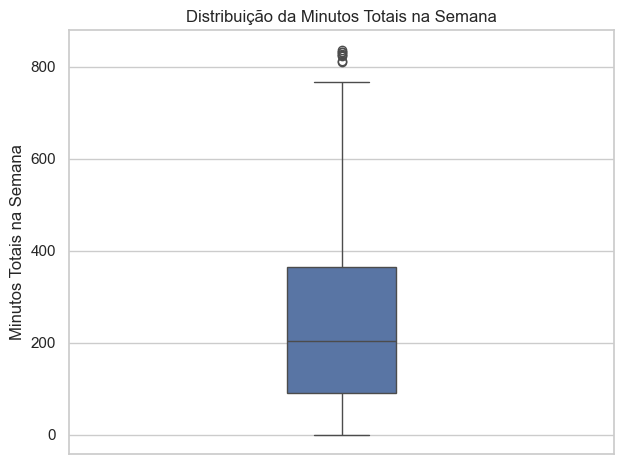

In [954]:
sns.set_theme(style='whitegrid')

sns.boxplot(data=df, y='minutos_totais_semana', width=0.2)

plt.title('Distribuição da Minutos Totais na Semana')
plt.ylabel('Minutos Totais na Semana')
plt.tight_layout()
plt.show()

In [955]:
df['minutos_totais_semana'].describe()

count    905.000000
mean     247.515138
std      198.721094
min        0.000000
25%       90.400000
50%      203.500000
75%      364.000000
max      837.200000
Name: minutos_totais_semana, dtype: float64

#### Conclusões:
- Outliers podem ser vistos, eles são pessoas com mais de 800 minutos de atividade física por semana. Essas pessoas são uma minoria de alunos com volume treino muito acima da média, possivelmente: atletas, praticantes de esportes competitivos e pessoas com rotina de treino intensa
- A assimetria para cima indica que uma parcela dos alunos treina mais que a maioria, puxando assim a distribuição para cima e justificando o uso da mediana para preencher os valores nulos, visto que o peso da mediana não é afetada pela distribuição assimétrica de dados

#### Preenchimento

In [956]:
# Preenchendo os valores nulos com a mediana
df['minutos_totais_semana'] = df['minutos_totais_semana'].fillna(df['minutos_totais_semana'].median())

In [957]:
# Checando se o preenchimento funcionou
df['minutos_totais_semana'].value_counts(normalize=True)  
df['minutos_totais_semana'].isnull().sum() # se funcionou, será printado '0'

np.int64(0)

Calculando os limites inferior e superior para saber mais precisamente quando que um valor é considerado um outlier (menor que o limite inferior ou maior que o limite inferior)

O IQR, ou, Amplitude Interquartil, é utilizado para saber a distância entre o Q1 e o Q3, descobrindo quais valores podem ser considerados dados centrais ou não

In [958]:
q1 = df['minutos_totais_semana'].quantile(0.25)
q3 = df['minutos_totais_semana'].quantile(0.75)
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print(f'Primeiro quartil (Q1): {q1}')
print(f'Terceito quartil (Q3): {q3}')
print(f'IQR: {iqr}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')

Primeiro quartil (Q1): 98.25
Terceito quartil (Q3): 345.82500000000005
IQR: 247.57500000000005
Limite inferior: -273.11250000000007
Limite superior: 717.1875000000001


In [959]:
mediana = df['minutos_totais_semana'].median() # criando uma variável com o valor da mediana

df['minutos_totais_semana'] = df['minutos_totais_semana'].apply( # percorrendo todos os valores e deixando o lambda substituir os valores que são maiores que os limites superiores pela mediana, caso seja menor ou igual ao limite superior o valor original é mantido
    lambda x: mediana if x > limite_superior else x
)

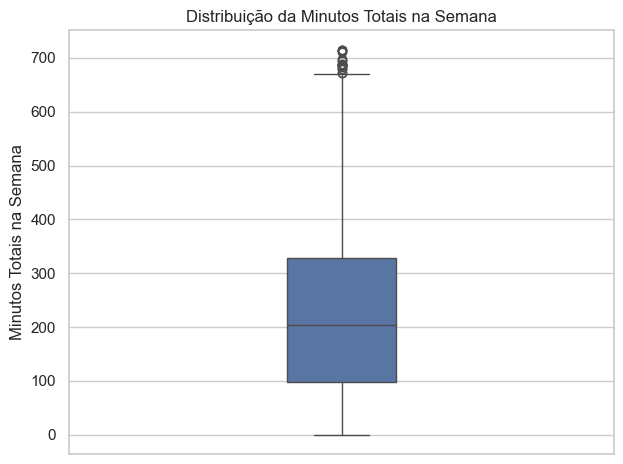

In [960]:
sns.boxplot(data=df, y='minutos_totais_semana', width=0.2)

plt.title('Distribuição da Minutos Totais na Semana')
plt.ylabel('Minutos Totais na Semana')
plt.tight_layout()
plt.show()

# Transformação de dados

Transformando a coluna 'data_matricula' no tipo de dado adequado (datetime)

In [961]:
df['data_matricula'] = pd.to_datetime(df['data_matricula'])

Criando a coluna da evolução do PGC

In [962]:
df['evolucao_pgc'] = df['primeiro_PGC'] - df['ultimo_PGC']

In [963]:
for coluna in colunas_categoricas:
    print(f'\nValores na coluna {coluna}: {df[coluna].unique()}')


Valores na coluna sexo: <StringArray>
['Outro', 'Masculino', 'Feminino']
Length: 3, dtype: str

Valores na coluna tipo_atividade: <StringArray>
[   'Natação',       'Yoga',     'Cardio',   'CrossFit', 'Musculação',
    'Futebol',    'Natacao',     'Soccer',        'Fut',   'Swimming']
Length: 10, dtype: str

Valores na coluna possui_nutricionista: <StringArray>
['Não', 'Sim']
Length: 2, dtype: str

Valores na coluna estado: <StringArray>
['Ativa', 'Sedentária']
Length: 2, dtype: str


Unificando valores redundantes

In [964]:
df['tipo_atividade'] = df['tipo_atividade'].replace({
    'Soccer': 'Futebol',
    'Fut': 'Futebol',
    'Swimming': 'Natação',
    'Natacao': 'Natação'
})

## Plotagem de gráficos

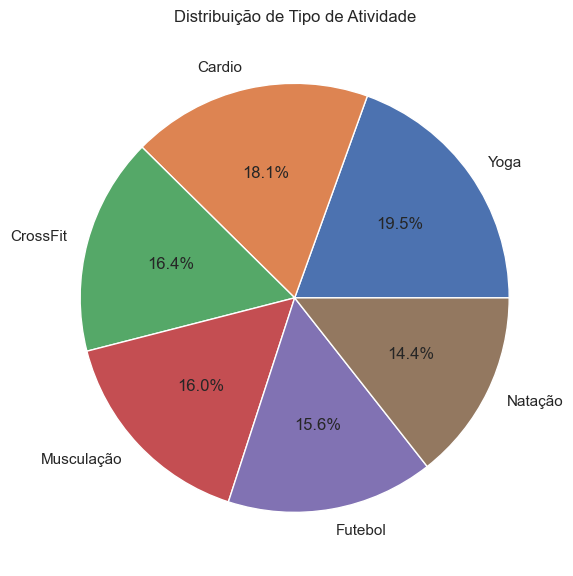

In [ ]:
# Distribuição de tipos de atividade
contagem = df['tipo_atividade'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(contagem, labels=contagem.index, autopct='%1.1f%%')
plt.title('Distribuição de Tipo de Atividade')
plt.tight_layout()
plt.show()

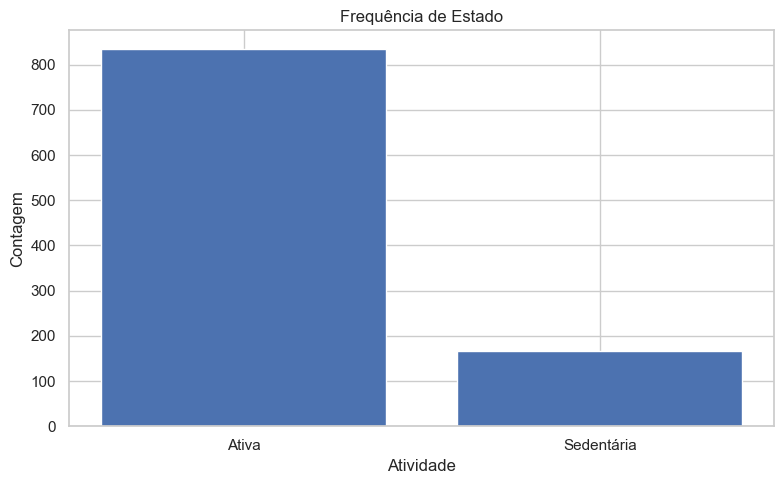

In [ ]:
# Contagem de pessoas ativas e sedentárias
plt.figure(figsize=(8, 5))
plt.bar(df['estado'].value_counts().index, df['estado'].value_counts().values)

plt.title('Frequência de Estado')
plt.xlabel('Atividade')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

## Transformando as colunas categóricas em flag binária

In [967]:
# coluna 'possui_nutricionista'
# Sim = 1, Não = 0
df['possui_nutricionista'] = df['possui_nutricionista'].str.strip().map({'Sim': 1, 'Não': 0, 'Nao': 0, 'não': 0, 'sim': 1})


# coluna 'estado'
# Ativa = 1, Sedentária = 0
df['estado'] = df['estado'].replace({'Ativa': 1, 'Sedentária': 0})


# coluna 'tipo_atividade'
# foi utilizada a técnica de One-Hot-Encoding
df = pd.get_dummies(df, columns=['tipo_atividade'], dtype=int)


df.head()

,idade,sexo,frequencia_semanal_treino,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado,evolucao_pgc,tipo_atividade_Cardio,tipo_atividade_CrossFit,tipo_atividade_Futebol,tipo_atividade_Musculação,tipo_atividade_Natação,tipo_atividade_Yoga
0,48,Outro,7.0,45.3,317.1,188.47,0,39.5,24.9,2021-07-28,1,14.6,0,0,0,0,1,0
1,30,Outro,7.0,98.1,686.7,198.07,0,25.2,23.5,2020-12-28,1,1.7,0,0,0,0,0,1
2,35,Masculino,5.0,33.9,169.5,154.90,0,27.2,11.4,2022-02-27,1,15.8,1,0,0,0,0,0
3,43,Outro,3.0,75.6,226.8,250.79,1,14.4,19.2,2022-12-01,1,-4.8,0,0,0,0,0,1
4,37,Masculino,0.0,114.0,0.0,168.02,1,21.5,18.1,2024-01-20,0,3.4,0,1,0,0,0,0


# Treinamento do modelo

In [968]:
# Decidir quais features manter, quais descartar
# A feature 'sexo' foi descartada pelo fato de ser eticamente questionável usar o gênero como fator de decisão para saber se o usuário é fisicamente ativo ou não
# A feature 'data_matricula' foi descartada por ser do tipo datetime, um tipo de dado que o StandardScaler não consegue processar diretamente, pois processa apenas dados numéricos
df = df.drop(columns=['sexo', 'data_matricula'])

In [969]:
# Colocando a variável dependente na última posição do dataset
features = [col for col in df.columns if col != 'estado']
features_target = features + ['estado']
df = df[features_target]

# Definindo as nossas features (X) e o target (y)
X = df.iloc[:, :-1] # todas as colunas menos a última
y = df.iloc[:, -1] # última coluna

df.head()

,idade,frequencia_semanal_treino,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,evolucao_pgc,tipo_atividade_Cardio,tipo_atividade_CrossFit,tipo_atividade_Futebol,tipo_atividade_Musculação,tipo_atividade_Natação,tipo_atividade_Yoga,estado
0,48,7.0,45.3,317.1,188.47,0,39.5,24.9,14.6,0,0,0,0,1,0,1
1,30,7.0,98.1,686.7,198.07,0,25.2,23.5,1.7,0,0,0,0,0,1,1
2,35,5.0,33.9,169.5,154.90,0,27.2,11.4,15.8,1,0,0,0,0,0,1
3,43,3.0,75.6,226.8,250.79,1,14.4,19.2,-4.8,0,0,0,0,0,1,1
4,37,0.0,114.0,0.0,168.02,1,21.5,18.1,3.4,0,1,0,0,0,0,0


In [970]:
# Checando as correlações
df.corr()

,idade,frequencia_semanal_treino,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,evolucao_pgc,tipo_atividade_Cardio,tipo_atividade_CrossFit,tipo_atividade_Futebol,tipo_atividade_Musculação,tipo_atividade_Natação,tipo_atividade_Yoga,estado
idade,1.000000,-0.019589,-0.006971,-0.055211,-0.012037,0.025632,0.029446,-0.010398,0.028692,-0.019594,-0.041233,0.029102,-0.005208,-0.011354,0.045803,0.011478
frequencia_semanal_treino,-0.019589,1.000000,-0.025565,0.731022,0.000493,-0.020836,-0.004278,-0.009392,0.003609,0.078897,-0.078088,-0.038672,0.023469,0.039189,-0.024718,0.478407
tempo_medio_exercicio,-0.006971,-0.025565,1.000000,0.430611,-0.037142,-0.003502,-0.030683,0.013153,-0.031551,0.009019,0.015644,0.018624,-0.096029,0.025481,0.025835,-0.043041
minutos_totais_semana,-0.055211,0.731022,0.430611,1.000000,-0.019363,-0.010418,-0.019253,-0.002371,-0.012219,0.068331,-0.054810,-0.028525,-0.034779,0.049761,-0.000969,0.416780
preco_plano,-0.012037,0.000493,-0.037142,-0.019363,1.000000,0.006910,-0.019262,-0.050226,0.021910,0.007237,0.002619,0.027115,-0.009856,-0.024040,-0.003891,0.015469
possui_nutricionista,0.025632,-0.020836,-0.003502,-0.010418,0.006910,1.000000,-0.006960,0.019078,-0.018638,-0.020610,0.028617,-0.026555,0.061343,-0.017005,-0.024088,-0.007120
primeiro_PGC,0.029446,-0.004278,-0.030683,-0.019253,-0.019262,-0.006960,1.000000,0.029922,0.701164,-0.026199,0.043294,0.000007,0.019926,-0.023940,-0.012231,-0.003333
ultimo_PGC,-0.010398,-0.009392,0.013153,-0.002371,-0.050226,0.019078,0.029922,1.000000,-0.691700,-0.014956,-0.018797,0.024828,0.033818,-0.024483,-0.000233,-0.044661
evolucao_pgc,0.028692,0.003609,-0.031551,-0.012219,0.021910,-0.018638,0.701164,-0.691700,1.000000,-0.008261,0.044689,-0.017705,-0.009726,0.000168,-0.008670,0.029450
tipo_atividade_Cardio,-0.019594,0.078897,0.009019,0.068331,0.007237,-0.020610,-0.026199,-0.014956,-0.008261,1.000000,-0.208217,-0.202110,-0.205172,-0.192815,-0.231375,0.000321


## Plotagem de gráficos necessários para entender nossos dados antes de treinar nosso modelo

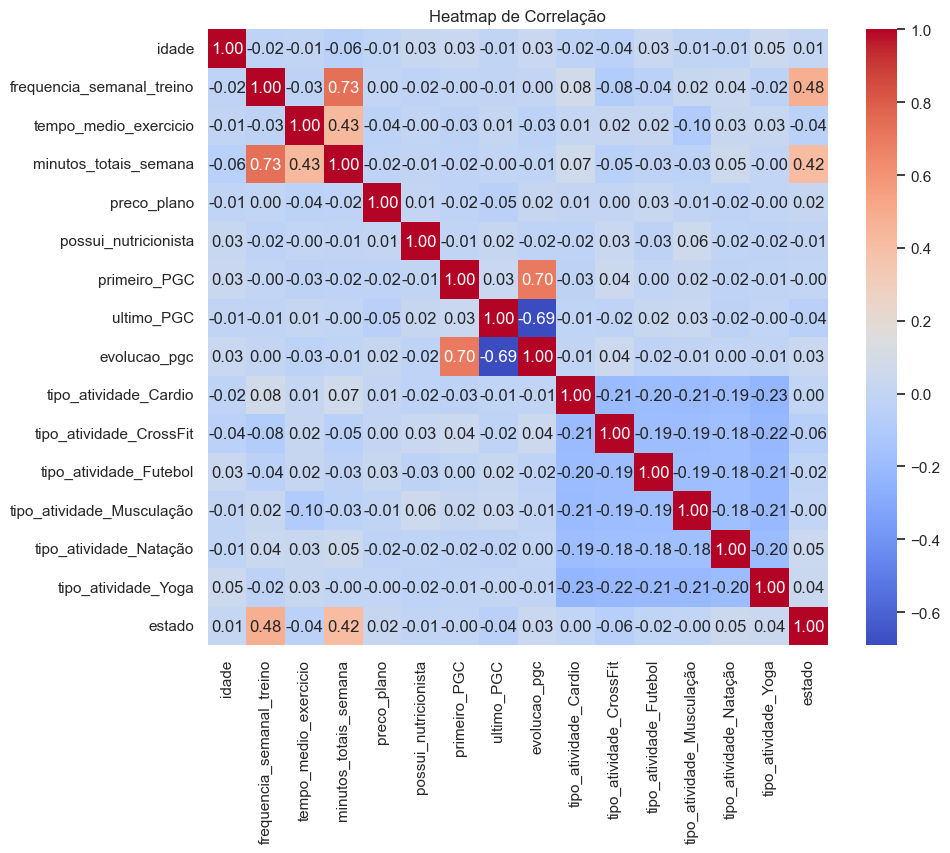

In [971]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap de Correlação')
plt.show()

#### Conclusões:
- A frequência semanal de treino é a feature mais correlacionada com o 'estado', o que faz bastante sentido. Já que quem passa mais tempo treinando na semana tem mais chance de ser ativo
- Os minutos totais na semana é a segunda feature mais forte, já que quem acumula mais minutos tende a ser ativo
- O tipo de atividade física que a pessoa pratica tem uma correlação fraca com o fato dela ser ativa ou sedentária

In [972]:
# Separando os conjuntos de treino e teste
# 80% treino e 20% teste
# número mágico 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

O Feature Scaling é utilizado para colocar todas as features na mesma escala 

Com o Feature Scaling o modelo consegue comparar duas features de forma justa

In [973]:
# Fazer o Feature Scaling (se necessário)
scaler = StandardScaler() # criando o objeto do scaler
X_train_scaled = scaler.fit_transform(X_train) # com a função 'fit_transform' o scaler aprende a média e o desvio padrão de cada coluna olhando pro X_train (fit) e aplica a transformação no X_train usando os valores que acabou de aprender (transform)
X_test_scaled = scaler.transform(X_test) # aplica o 'transform' sem o 'fit'
print("Features standardized")

Features standardized


In [974]:
# Criando o modelo (usando uma classe do sklearn)
# Nesse exemplo é Regressão Logística
model = LogisticRegression(random_state=42)

In [975]:
# Convertendo o target de float para int, visto que o LogisticRegression exige que as classes sejam valores inteiros discretos (0 e 1), não decimais
# Foi necessária a conversão pelo fato do replace do pandas ter armazenado o 0 e 1 como 1.0 e 0.0 (float) 
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [976]:
# Treinar o modelo
# Ele vai calcular o erro, o gradiente, e atualizar os pesos
# Isso vai criar o modelo, e ele vai ser capaz de fazer previsões (criando a função de inferência)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [977]:
# Fazer o teste e as previsões necessárias
y_pred = model.predict(X_test_scaled) # faz as previsões do modelo para cada conjutno de teste
y_pred_proba = model.predict_proba(X_test_scaled) # retorna a probabilidade de cada classe

In [978]:
# Fazer a avaliação do modelo
accuracy = accuracy_score(y_test, y_pred) # acurácia do modelo
print(f"Accuracy: {accuracy:.4f}") 
print(classification_report(y_test, y_pred)) # relatório mais detalhado sobre as métricas do nosso modelo
print(confusion_matrix(y_test, y_pred)) # matriz de confusão


Accuracy: 0.9150
              precision    recall  f1-score   support

           0       0.83      0.61      0.70        33
           1       0.93      0.98      0.95       167

    accuracy                           0.92       200
   macro avg       0.88      0.79      0.83       200
weighted avg       0.91      0.92      0.91       200

[[ 20  13]
 [  4 163]]


In [979]:
print(f"\n=== Conclusão da análise ===")
if accuracy > 0.95:
    print("Excelente: Modelo demonstra performance excepcional.")
elif accuracy > 0.90:
    print("Muito bom: Modelo apresenta alta acurácia.")
elif accuracy > 0.85:
    print("Bom : Modelo apresenta boa performance.")
else:
    print("Melhorias necessárias: Modelo precisa de ajustes.")


=== Conclusão da análise ===
Muito bom: Modelo apresenta alta acurácia.
